In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import seaborn as sns
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams.update({
    "font.size": 16,        # base font
    "axes.titlesize": 20,   # title
    "axes.labelsize": 18,   # x/y labels
    "xtick.labelsize": 16,  # x tick labels
    "ytick.labelsize": 16,  # y tick labels
    "legend.fontsize": 16,  # legend
})

In [ ]:
def Lambda(x):
    return np.exp(-x)

def H(x):
    if x >= -1:
        return np.exp(-(x+1))
    return -x

def F(x):
    if x+1 >= 0:
        return x+1
    return 0

In [14]:
Q = 10
gamma = 1
sigma = 1.0
T = 100

V(0,0) = 34.14534173830302
Check terminal condition: V(T,0) = 0.0


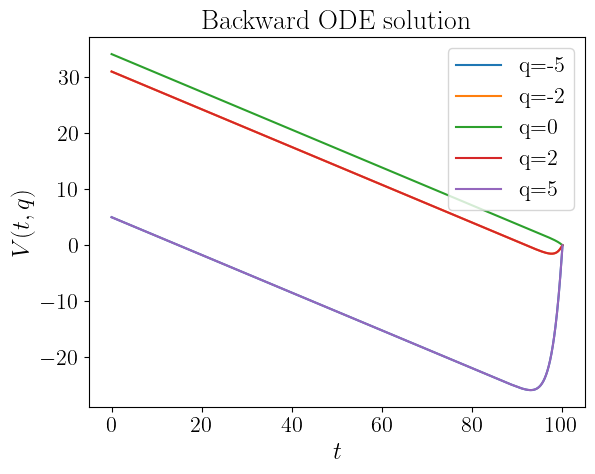

In [15]:
# Inventory grid q in {-Q, ..., Q}
qs = np.arange(-Q, Q + 1, dtype=int)
n = len(qs)


# Inventory-penalization term
def running_term(t, q):
    return 0.5 * gamma * sigma**2 * q**2


# RHS of the ODE system
def rhs(t, v):
    dv = np.zeros_like(v)

    for i, q in enumerate(qs):
        val = running_term(t, q)
        if q > -Q:
            val -= H(v[i] - v[i - 1])
        if q < Q:
            val -= H(v[i] - v[i + 1])

        dv[i] = val
    return dv


# Time grid for backward solve (must be decreasing because we solve from T to 0)
t_eval = np.linspace(T, 0.0, 2000)

# Terminal condition vector (v(T,q) = 0 for all q)
vT = np.zeros(n)

# Solve backward ODE
sol = solve_ivp(
    fun=rhs,
    t_span=(T, 0.0),
    y0=vT,
    t_eval=t_eval,
)

if not sol.success:
    raise RuntimeError(f"ODE solve failed: {sol.message}")

# Build interpolation helper v_of_t_q(t, q)
ts = sol.t          # descending
vs = sol.y          # shape (n_q, n_t)

q_to_idx = {q: i for i, q in enumerate(qs)}


def v_of_t_q(t, q):
    if q not in q_to_idx:
        raise ValueError(f"q must be in {qs.tolist()}")
    i = q_to_idx[q]
    return np.interp(t, ts[::-1], vs[i, ::-1])


# Checks
print("V(0,0) =", v_of_t_q(0.0, 0))
print("Check terminal condition: V(T,0) =", v_of_t_q(T, 0))


# Plot v(t,q) for a few q values
for q in [-5, -2, 0, 2, 5]:
    i = q_to_idx[q]
    plt.plot(sol.t[::-1], sol.y[i, ::-1], label=f"q={q}")

plt.xlabel(r"$t$")
plt.ylabel(r"$V(t,q)$")
plt.title("Backward ODE solution")
plt.legend()
plt.show()